# Carbon-Aware CI Scheduling — 24-Hour Forecast Analysis

This notebook fetches a live 24-hour CO₂ intensity forecast from the **WattTime v3 API**, identifies the lowest-carbon hour, and outputs the corresponding **`cron` expression** you can drop directly into a GitHub Actions workflow.

### Which region is used?
The WattTime account in this project has access to **`CAISO_NORTH`** (California ISO) only.  
Querying `MISO_MASON_CITY` (`centralus`) returns **403 Forbidden** — that region is not in the account's authorised list (`/v3/my-access`).  
**`CAISO_NORTH`** is equivalent to Azure **`westus`** (lat 37.78 / lon -122.42, San Francisco).

---

## 1 · Imports & Credentials

In [1]:
import os
import requests
from datetime import datetime, timezone
from collections import defaultdict
import statistics
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

load_dotenv()
USERNAME = os.getenv('USERNAMME')
PASSWORD = os.getenv('PASSWORD')
assert USERNAME and PASSWORD, 'Missing WattTime credentials — check your .env file'
print(f'Credentials loaded for user: {USERNAME}')

Credentials loaded for user: AndreiPaduraru


## 2 · Authenticate with WattTime v3

In [2]:
resp = requests.get('https://api.watttime.org/login', auth=(USERNAME, PASSWORD))
resp.raise_for_status()
TOKEN = resp.json()['token']
HEADERS = {'Authorization': f'Bearer {TOKEN}'}
print(f'Authenticated. Token prefix: {TOKEN[:20]}...')

Authenticated. Token prefix: eyJhbGciOiJSUzI1NiIs...


## 3 · Inspect Account Access

The `/v3/my-access` endpoint shows which regions and signal types this account tier allows.

In [3]:
access = requests.get('https://api.watttime.org/v3/my-access', headers=HEADERS).json()
print('=== Authorised regions for this account ===')
for sig in access.get('signal_types', []):
    print(f"\nSignal type: {sig['signal_type']}")
    for region in sig.get('regions', []):
        endpoints = [e['endpoint'] for e in region.get('endpoints', [])]
        print(f"  {region['region']:30s} ({region['region_full_name']})")
        print(f"    Endpoints: {', '.join(endpoints)}")

=== Authorised regions for this account ===

Signal type: co2_moer
  CAISO_NORTH                    (California ISO Northern)
    Endpoints: v3/historical, v3/forecast

Signal type: health_damage
  CAISO_NORTH                    (California ISO Northern)
    Endpoints: v3/historical, v3/forecast


## 4 · Fetch 24-Hour Forecast for CAISO_NORTH

In [4]:
REGION = 'CAISO_NORTH'
SIGNAL = 'co2_moer'
LBS_MWH_TO_G_KWH = 453.592 / 1000

resp = requests.get(
    'https://api.watttime.org/v3/forecast',
    headers=HEADERS,
    params={'region': REGION, 'signal_type': SIGNAL, 'horizon_hours': 24},
)
resp.raise_for_status()

forecast_points = [
    (
        datetime.fromisoformat(pt['point_time']).astimezone(timezone.utc),
        round(float(pt['value']) * LBS_MWH_TO_G_KWH, 2),
    )
    for pt in resp.json()['data']
]
print(f'Fetched {len(forecast_points)} data points (5-min resolution) for {REGION}')
print(f"Window: {forecast_points[0][0].strftime('%Y-%m-%d %H:%M UTC')} -> {forecast_points[-1][0].strftime('%Y-%m-%d %H:%M UTC')}")

Fetched 288 data points (5-min resolution) for CAISO_NORTH
Window: 2026-03-18 21:25 UTC -> 2026-03-19 21:20 UTC


## 5 · Compute Hourly Averages

In [5]:
hourly_buckets = defaultdict(list)
for ts, g_co2 in forecast_points:
    hourly_buckets[ts.replace(minute=0, second=0, microsecond=0)].append(g_co2)

hourly = sorted(
    [{'hour': h, 'avg': round(statistics.mean(v), 1), 'min': round(min(v), 1)}
     for h, v in hourly_buckets.items()],
    key=lambda x: x['hour']
)
ranked = sorted(hourly, key=lambda x: x['avg'])
best_hour = ranked[0]

print(f"{'Hour (UTC)':<22} {'Avg g CO2/kWh':>14} {'Min g CO2/kWh':>14}")
print('-' * 52)
for row in ranked:
    marker = ' <- BEST' if row['hour'] == best_hour['hour'] else ''
    print(f"{row['hour'].strftime('%m/%d %H:00 UTC'):<22} {row['avg']:>14.1f} {row['min']:>14.1f}{marker}")

Hour (UTC)              Avg g CO2/kWh  Min g CO2/kWh
----------------------------------------------------
03/18 21:00 UTC                   0.0            0.0 <- BEST
03/18 22:00 UTC                   0.0            0.0
03/18 23:00 UTC                   0.0            0.0
03/19 16:00 UTC                   0.0            0.0
03/19 17:00 UTC                   0.0            0.0
03/19 18:00 UTC                   0.0            0.0
03/19 19:00 UTC                   0.0            0.0
03/19 20:00 UTC                   0.0            0.0
03/19 21:00 UTC                   0.0            0.0
03/19 15:00 UTC                  90.9            0.0
03/19 00:00 UTC                 119.7           53.4
03/19 14:00 UTC                 422.4          402.9
03/19 09:00 UTC                 435.8          432.4
03/19 03:00 UTC                 437.5          434.4
03/19 12:00 UTC                 440.6          404.8
03/19 01:00 UTC                 441.2          424.9
03/19 02:00 UTC                 442.6 

## 6 · Visualise — 24-Hour Forecast with Best Hour Highlighted

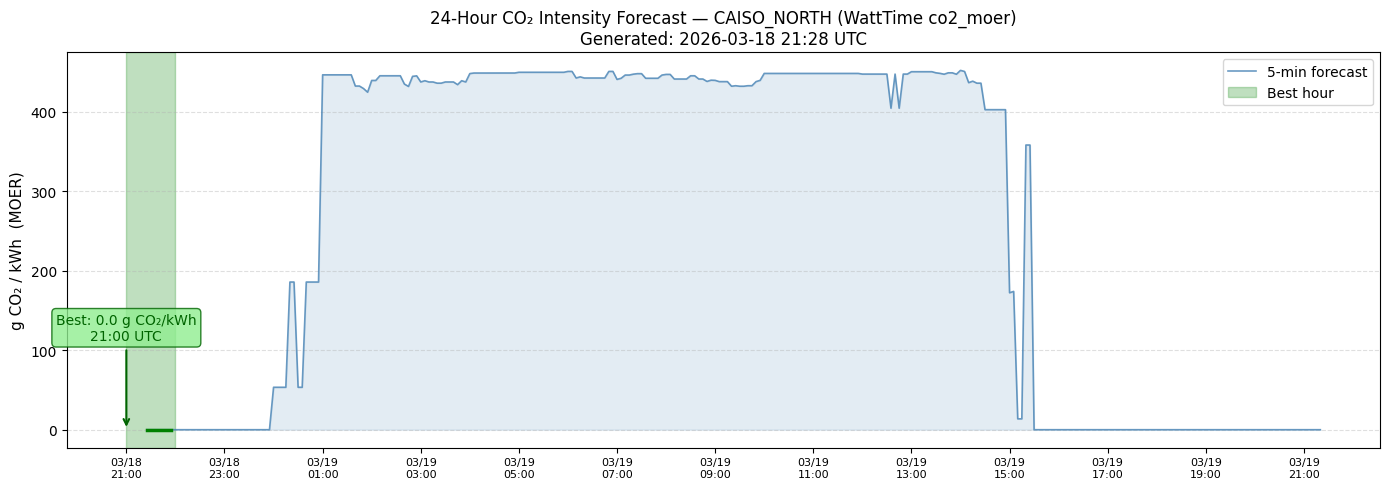

Chart saved to img/forecast_best_hour.png


In [6]:
times  = [ts for ts, _ in forecast_points]
values = [v  for _, v  in forecast_points]

best_start = best_hour['hour']
best_end   = best_start.replace(minute=59, second=59)
best_times  = [t for t in times if best_start <= t <= best_end]
best_values = [v for t, v in forecast_points if best_start <= t <= best_end]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(times, values, color='steelblue', linewidth=1.2, alpha=0.8, label='5-min forecast')
ax.fill_between(times, values, color='steelblue', alpha=0.15)
ax.axvspan(best_start, best_end, color='green', alpha=0.25, label='Best hour')
ax.plot(best_times, best_values, color='green', linewidth=2.5)
ax.annotate(
    f"Best: {best_hour['avg']} g CO\u2082/kWh\n{best_start.strftime('%H:00 UTC')}",
    xy=(best_start, best_hour['min']),
    xytext=(best_start, best_hour['min'] + max(values) * 0.25),
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
    fontsize=10, color='darkgreen', ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', edgecolor='darkgreen', alpha=0.8),
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=0, fontsize=8)
ax.set_ylabel('g CO\u2082 / kWh  (MOER)', fontsize=11)
ax.set_title(
    f'24-Hour CO\u2082 Intensity Forecast \u2014 {REGION} (WattTime co2_moer)\n'
    f"Generated: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}",
    fontsize=12,
)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/forecast_best_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to img/forecast_best_hour.png')

## 7 · GitHub Actions Recommendation

In [7]:
cron_hour = best_hour['hour'].hour
top5 = ranked[:5]
worst = ranked[-1]
saving_pct = round((1 - best_hour['avg'] / worst['avg']) * 100, 1)

print('=' * 60)
print(' BEST TIME TO RUN A GITHUB ACTION (next 24 h)')
print('=' * 60)
print(f' Region  : {REGION} (Azure westus)')
print( ' Signal  : WattTime co2_moer (Marginal Emissions Rate)')
print()
print(' Top 5 cleanest hours:')
for i, row in enumerate(top5, 1):
    print(f"   {i}. {row['hour'].strftime('%m/%d %H:00 UTC')}  =>  {row['avg']:6.1f} g CO2/kWh")
print()
print(f" Best hour : {best_hour['hour'].strftime('%m/%d %H:00 UTC')}")
print(f" Average   : {best_hour['avg']} g CO2/kWh")
print(f" Minimum   : {best_hour['min']} g CO2/kWh")
print()
print(' GitHub Actions cron schedule (UTC):')
print()
print('   on:')
print('     schedule:')
print(f"       - cron: '0 {cron_hour} * * *'")
print()
print(f" vs worst hour ({worst['hour'].strftime('%H:00 UTC')}, {worst['avg']} g CO2/kWh):")
print(f" Running at best hour saves ~{saving_pct}% of carbon emissions.")
print('=' * 60)

 BEST TIME TO RUN A GITHUB ACTION (next 24 h)
 Region  : CAISO_NORTH (Azure westus)
 Signal  : WattTime co2_moer (Marginal Emissions Rate)

 Top 5 cleanest hours:
   1. 03/18 21:00 UTC  =>     0.0 g CO2/kWh
   2. 03/18 22:00 UTC  =>     0.0 g CO2/kWh
   3. 03/18 23:00 UTC  =>     0.0 g CO2/kWh
   4. 03/19 16:00 UTC  =>     0.0 g CO2/kWh
   5. 03/19 17:00 UTC  =>     0.0 g CO2/kWh

 Best hour : 03/18 21:00 UTC
 Average   : 0.0 g CO2/kWh
 Minimum   : 0.0 g CO2/kWh

 GitHub Actions cron schedule (UTC):

   on:
     schedule:
       - cron: '0 21 * * *'

 vs worst hour (05:00 UTC, 450.0 g CO2/kWh):
 Running at best hour saves ~100.0% of carbon emissions.
